In [1]:
# Standard imports
import polars as pl
import numpy as np
from pathlib import Path
from sklearn.preprocessing import OrdinalEncoder

# LightGBM
import lightgbm as lgb

# Scikit-learn metrics (reusing from baseline)
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.calibration import calibration_curve

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Matplotlib and seaborn styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Configuration
from IPython.display import display
import time

# Polars settings
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(15)

# Paths
TRAIN_PATH = Path("../data/interim/train_split.parquet")
VAL_PATH = Path("../data/interim/val_split.parquet")

print(f"Polars version: {pl.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"Train file exists: {TRAIN_PATH.exists()}")
print(f"Val file exists: {VAL_PATH.exists()}")

Polars version: 1.39.3
LightGBM version: 4.3.0
Train file exists: True
Val file exists: True


### Load and preprocess data for LightGBM

In [2]:
# Load train and val as lazy frames
train_lazy = pl.scan_parquet(TRAIN_PATH)
val_lazy = pl.scan_parquet(VAL_PATH)

# Add time features
def add_time_features(df):
    """Extract hour_of_day, day_of_week, and is_weekend from 'hour' column."""
    return (
        df
        .with_columns(
            pl.col("hour").cast(pl.String).alias("hour_str")
        )
        .with_columns([
            pl.col("hour_str").str.slice(4, 2).cast(pl.Int8).alias("day"),
            pl.col("hour_str").str.slice(6, 2).cast(pl.Int8).alias("hour_of_day"),
        ])
        .with_columns(
            ((pl.col("day") - 21 + 1) % 7).alias("day_of_week")
        )
        .with_columns(
            pl.col("day_of_week").is_in([5, 6]).alias("is_weekend")
        )
        .drop("hour_str")
    )

train_lazy = add_time_features(train_lazy)
val_lazy = add_time_features(val_lazy)

# Add is app flag
SITE_PLACEHOLDER_IN_APP_ID = "ecad2386"

train_lazy = train_lazy.with_columns(
    (pl.col("app_id") != SITE_PLACEHOLDER_IN_APP_ID).alias("is_app")
)
val_lazy = val_lazy.with_columns(
    (pl.col("app_id") != SITE_PLACEHOLDER_IN_APP_ID).alias("is_app")
)

# Drop columns we don't need or are problematic
DROP_COLS = ["id", "hour", "day","device_id", "device_ip"]

# Collect to full DataFrames
print("Loading train...")
train = train_lazy.drop(DROP_COLS).collect()
print(f"Train shape: {train.shape}")

print("Loading val...")
val = val_lazy.drop(DROP_COLS).collect()
print(f"Val shape: {val.shape}")

Loading train...
Train shape: (32377421, 24)
Loading val...
Val shape: (8051546, 24)


In [3]:
# Separate features and target, convert to pandas (for LightGBM)
def prepare_xy(df):
    """Separate features from target. Convert to pandas (good format for LightGBM)."""
    y = df["click"].to_numpy()
    X = df.drop("click").to_pandas()
    return X, y

X_train, y_train = prepare_xy(train)
X_val, y_val = prepare_xy(val)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"\nX_train dtypes:")
print(X_train.dtypes)

X_train shape: (32377421, 23)
X_val shape: (8051546, 23)
y_train shape: (32377421,)
y_val shape: (8051546,)

X_train dtypes:
C1                   int32
banner_pos            int8
site_id             object
site_domain         object
site_category       object
app_id              object
app_domain          object
app_category        object
device_model        object
device_type           int8
device_conn_type      int8
C14                  int32
C15                  int16
C16                  int16
C17                  int32
C18                   int8
C19                  int16
C20                  int32
C21                  int16
hour_of_day           int8
day_of_week           int8
is_weekend            bool
is_app                bool
dtype: object


#### 3 groups of data:
- integer type (e.g., C1, banner_pos, device_type) - should be treated as categories anyway by the model - need conversion to category type for LightGBM
- object type (e.g., site_id, app_id, device_ip) - strings, explicitly categorical but need conversion to category type for LightGBM
- bool type (is_weekend, is_app) - our flags, understood by LightGBM natively

In [4]:
# List of categorical columns
CATEGORICAL_COLS = [
    # Integer columns
    "C1", "banner_pos", "device_type", "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21",
    "hour_of_day", "day_of_week",
    # Object (string) columns
    "site_id", "site_domain", "site_category",
    "app_id", "app_domain", "app_category",
    "device_model",
]

# Ordinal encoder - converts categories to integer codes
# Uses same encoding for train and val
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.int32
)

print("Encoding categorical columns to integer codes...")
X_train[CATEGORICAL_COLS] = encoder.fit_transform(X_train[CATEGORICAL_COLS])
X_val[CATEGORICAL_COLS] = encoder.transform(X_val[CATEGORICAL_COLS])

# Convert boolean columns to int8
X_train["is_weekend"] = X_train["is_weekend"].astype("int8")
X_train["is_app"] = X_train["is_app"].astype("int8")
X_val["is_weekend"] = X_val["is_weekend"].astype("int8")
X_val["is_app"] = X_val["is_app"].astype("int8")

print(f"X_train shape: {X_train.shape}")
print(f"X_train dtypes (first few):")
print(X_train.dtypes.head(10))
print(f"\nMemory usage: {X_train.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Encoding categorical columns to integer codes...
X_train shape: (32377421, 23)
X_train dtypes (first few):
C1               int32
banner_pos       int32
site_id          int32
site_domain      int32
site_category    int32
app_id           int32
app_domain       int32
app_category     int32
device_model     int32
device_type      int32
dtype: object

Memory usage: 2.78 GB


In [5]:
# Check details about the data
print(f"X_train shape: {X_train.shape}")
print(f"X_train memory: {X_train.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"\nCategorical columns and their cardinality:")
for col in X_train.columns:
    if X_train[col].dtype.name == "category":
        n_cat = len(X_train[col].cat.categories)
        print(f"  {col}: {n_cat:,} categories")

X_train shape: (32377421, 23)
X_train memory: 2.78 GB

Categorical columns and their cardinality:


### Parameters for baseline LghtGBM

In [6]:
# LightGBM parameters - baseline
params = {
    # Core parameters
    "objective": "binary", # binary classification - click/no-click
    "metric": "binary_logloss", # what to evaluate during training

    # Tree structure
    "num_leaves": 63, # complexity of each tree (2^6-1 = 63)
    "min_data_in_leaf": 100, # minimum samples per leaf (avoiding overfitting)

    # Learning
    "learning_rate": 0.1, # how fast to learn (lower - need more trees, but more precise)
    "feature_fraction": 0.9, # randomly use 90% of features (per tree)
    "bagging_fraction": 0.8, # randomly use 80% of data (per tree)
    "bagging_freq": 5, # bagging every 5 iterations

    # Regularization
    "lambda_l1": 0.1, # L1 regularization for leaf weights
    "lambda_l2": 0.1, # L2 regularization

    # Performance
    "n_jobs": 1, # use 1 CPU core
    "verbose": -1, # no verbose messages
}

print("LightGBM parameters defined.")
print(f"num_leaves: {params['num_leaves']}")
print(f"learning_rate: {params['learning_rate']}")

LightGBM parameters defined.
num_leaves: 63
learning_rate: 0.1


In [8]:
# Get column indices for categorical features
categorical_indices = [X_train.columns.get_loc(col) for col in CATEGORICAL_COLS]

# Create LightGBM datasets
print("Creating LightGBM dataset for train...")
train_data = lgb.Dataset(
    X_train.values,
    label=y_train,
    categorical_feature=categorical_indices,
    free_raw_data=False # keep X_train accessible for later
)

print("Creating LightGBM dataset for val...")
val_data = lgb.Dataset(
    X_val.values,
    label=y_val,
    categorical_feature=categorical_indices,
    reference=train_data, # using the same category encoding as for train
    free_raw_data=False # keep X_val accessible for later
)

print("Done.")

Creating LightGBM dataset for train...
Creating LightGBM dataset for val...
Done.


## Model Training

In [9]:
# Train with early stopping
print("Training LightGBM...")

start_time = time.time()

model = lgb.train(
    params = params,
    train_set = train_data,
    num_boost_round = 500, # max number of trees
    valid_sets = [train_data, val_data], # datasets to evaluate on
    valid_names = ["train","val"], 
    callbacks = [
        lgb.early_stopping(stopping_rounds=20), # stop if no improvement for 20 rounds
        lgb.log_evaluation(period=25) # print metrics every  25 trees
    ]
)

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed} seconds ({elapsed / 60:.1f} minutes)")
print(f"Best iteration: {model.best_iteration}")
print(f"Best score: {model.best_score}")

Training LightGBM...
Training until validation scores don't improve for 20 rounds
[25]	train's binary_logloss: 0.400606	val's binary_logloss: 0.396051
[50]	train's binary_logloss: 0.395934	val's binary_logloss: 0.392181
[75]	train's binary_logloss: 0.393941	val's binary_logloss: 0.390661
[100]	train's binary_logloss: 0.392691	val's binary_logloss: 0.389844
[125]	train's binary_logloss: 0.391841	val's binary_logloss: 0.389449
[150]	train's binary_logloss: 0.391273	val's binary_logloss: 0.389222
[175]	train's binary_logloss: 0.390783	val's binary_logloss: 0.3891
[200]	train's binary_logloss: 0.390377	val's binary_logloss: 0.388967
[225]	train's binary_logloss: 0.389986	val's binary_logloss: 0.388923
Early stopping, best iteration is:
[211]	train's binary_logloss: 0.39019	val's binary_logloss: 0.388919

Training completed in 1274.9725351333618 seconds (21.2 minutes)
Best iteration: 211
Best score: defaultdict(<class 'collections.OrderedDict'>, {'train': OrderedDict([('binary_logloss', 0.3

## Model evaluation

In [10]:
# Predict probabilities on val
y_val_pred_proba = model.predict(X_val.values, num_iteration=model.best_iteration)

# Sanity check
print(f"Prediction range: [{y_val_pred_proba.min():.4f}, {y_val_pred_proba.max():.4f}]")
print(f"Mean prediction: {y_val_pred_proba.mean():.4f}")
print(f"Val CTR (actual): {y_val.mean():.4f}")

Prediction range: [0.0001, 0.9878]
Mean prediction: 0.1675
Val CTR (actual): 0.1632


### Metrics

In [12]:
# Baseline - trivial model predicting constant mean CTR
baseline_pred = np.full(len(y_val), y_train.mean())

# LightGBM metrics
log_loss_lgb = log_loss(y_val, y_val_pred_proba)
auc_lgb = roc_auc_score(y_val, y_val_pred_proba)

# Baseline metrics
log_loss_baseline = log_loss(y_val, baseline_pred)

# Compare with Day 4 Logistic Regression (from memory)
log_loss_lr = 0.3970
auc_lr = 0.7321

print("BASELINE (constant):")
print(f"  Log loss: {log_loss_baseline:.4f}")

print("\nLOGISTIC REGRESSION (SGD):")
print(f"  Log loss: {log_loss_lr:.4f}")
print(f"  AUC:      {auc_lr:.4f}")

print("\nLIGHTGBM:")
print(f"  Log loss: {log_loss_lgb:.4f}")
print(f"  AUC:      {auc_lgb:.4f}")

print("\nIMPROVEMENT OVER LR:")
print(f"  Log loss reduction: {log_loss_lr - log_loss_lgb:.4f} ({(log_loss_lr - log_loss_lgb) / log_loss_lr * 100:.2f}%)")
print(f"  AUC gain: {auc_lgb - auc_lr:.4f}")

BASELINE (constant):
  Log loss: 0.4452

LOGISTIC REGRESSION (SGD):
  Log loss: 0.3970
  AUC:      0.7321

LIGHTGBM:
  Log loss: 0.3889
  AUC:      0.7466

IMPROVEMENT OVER LR:
  Log loss reduction: 0.0081 (2.04%)
  AUC gain: 0.0145


### Feature importance

In [13]:
# Feature importance - two types
importance_gain = model.feature_importance(importance_type="gain")
importance_split = model.feature_importance(importance_type="split")

# Create DataFrame for easier analysis
import pandas as pd
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "gain": importance_gain,
    "split": importance_split,
}).sort_values("gain", ascending=False)

print("Top 15 features by GAIN:")
print(importance_df.head(15).to_string(index=False))

print("\nTop 15 features by SPLIT:")
print(importance_df.sort_values("split", ascending=False).head(15).to_string(index=False))

Top 15 features by GAIN:
         feature         gain  split
             C17 5.657200e+06    867
             C21 2.657897e+06     49
         site_id 2.442995e+06   1844
     site_domain 1.953547e+06    972
          app_id 1.845319e+06   1396
    device_model 1.666303e+06   5274
             C14 9.296790e+05   1602
      app_domain 6.966624e+05    125
     hour_of_day 1.853066e+05    199
             C20 1.702218e+05    338
   site_category 1.374359e+05     63
      banner_pos 1.139067e+05     76
    app_category 8.119489e+04     57
              C1 4.914209e+04     23
device_conn_type 4.622916e+04     63

Top 15 features by SPLIT:
         feature         gain  split
    device_model 1.666303e+06   5274
         site_id 2.442995e+06   1844
             C14 9.296790e+05   1602
          app_id 1.845319e+06   1396
     site_domain 1.953547e+06    972
             C17 5.657200e+06    867
             C20 1.702218e+05    338
     hour_of_day 1.853066e+05    199
      app_domain 6.9666

In [14]:
# Show all features sorted by gain
print("All features by gain:")
print(importance_df.to_string(index=False))

All features by gain:
         feature         gain  split
             C17 5.657200e+06    867
             C21 2.657897e+06     49
         site_id 2.442995e+06   1844
     site_domain 1.953547e+06    972
          app_id 1.845319e+06   1396
    device_model 1.666303e+06   5274
             C14 9.296790e+05   1602
      app_domain 6.966624e+05    125
     hour_of_day 1.853066e+05    199
             C20 1.702218e+05    338
   site_category 1.374359e+05     63
      banner_pos 1.139067e+05     76
    app_category 8.119489e+04     57
              C1 4.914209e+04     23
device_conn_type 4.622916e+04     63
     day_of_week 2.793336e+04     74
             C19 2.314534e+04     26
             C16 4.900879e+03     14
     device_type 4.038148e+03      5
          is_app 3.649659e+03      3
             C15 1.397658e+03      5
      is_weekend 6.834176e+02      7
             C18 0.000000e+00      0


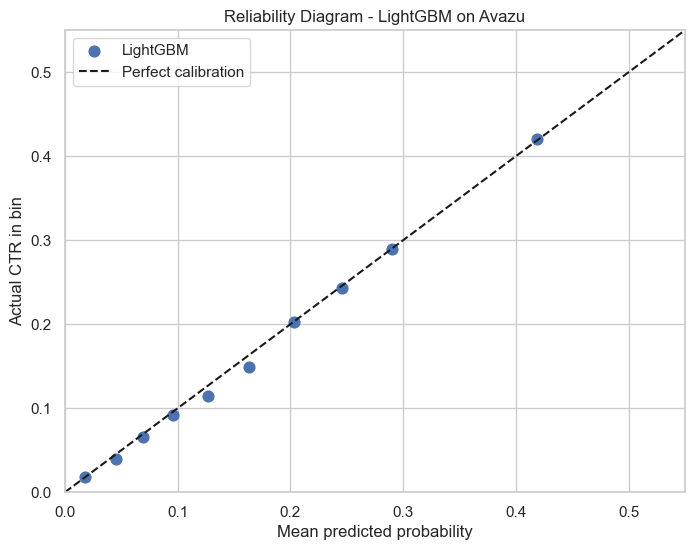


Calibration table:
  Bin 1: predicted 0.017, actual 0.018, diff -0.000
  Bin 2: predicted 0.045, actual 0.039, diff +0.006
  Bin 3: predicted 0.069, actual 0.065, diff +0.004
  Bin 4: predicted 0.096, actual 0.092, diff +0.004
  Bin 5: predicted 0.127, actual 0.114, diff +0.012
  Bin 6: predicted 0.163, actual 0.149, diff +0.015
  Bin 7: predicted 0.203, actual 0.202, diff +0.001
  Bin 8: predicted 0.246, actual 0.243, diff +0.003
  Bin 9: predicted 0.290, actual 0.290, diff +0.001
  Bin 10: predicted 0.419, actual 0.421, diff -0.002


In [15]:
prob_true, prob_pred = calibration_curve(
    y_val, 
    y_val_pred_proba, 
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(8, 6))
plt.scatter(prob_pred, prob_true, s=60, label="LightGBM")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual CTR in bin")
plt.title("Reliability Diagram - LightGBM on Avazu")
plt.legend()
plt.grid(True)
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.show()

print("\nCalibration table:")
for i in range(len(prob_pred)):
    print(f"  Bin {i+1}: predicted {prob_pred[i]:.3f}, actual {prob_true[i]:.3f}, diff {prob_pred[i] - prob_true[i]:+.3f}")